<h1 style=\"text-align: center; font-size: 75px;\"> ⚙️ Run Workflow: Agentic Audio RAG </h1>

📘 Project Overview: 
 This notebook demonstrates a modular architecture for answering natural language questions 
 over one or more audio/video files documents using only local and open-source models (e.g., Qwen Omni).
 The system processes audio embeddings and synthesizes a final answer using a multi-step LLM workflow.

# Notebook Overview

- Start Execution
- Define User Constants
- Install and Import Libraries
- Configure Settings
- Verify Assets
- KV Memory
- LLM Setup
- State Model
- Node Functions
- Graph Definition
- Graph Visualization
- Generated Answer
- Message History

# Start Execution

In [3]:
# Standard library imports
import os  # Provides OS-related utilities
import sys  # Allows manipulation of Python runtime environment
import time  # Enables time-based operations
from pathlib import Path  # Object-oriented file system paths

# Extend sys.path to allow importing from parent directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Local application-specific imports
from src.simple_kv_memory import SimpleKVMemory  # In-memory key-value store for agent state
from src.model_selection import ModelSelector
from src.utils import (  # Utility functions for logging, LLM I/O, and schema generation
    load_config,
    load_secrets,
    load_secrets_to_env,
    configure_proxy,
    display_image,
    get_project_root,
    get_response_from_llm,
    json_schema_from_type,
    log_timing,
    sec_to_timestamp,
    logger,
    login_huggingface,
    setup_model_environment,
    ensure_wav,
    initialize_llm
)

In [4]:
start_time = time.time()  
logger.info("Notebook execution started.")

# Define User Constants

In [5]:
QUESTION: str = "What is the main idea of the content?"
DOCS: list
FILE_ID: str
MEMORY: SimpleKVMemory
INPUT_PATH: Path = Path("../data/input")

# Install and Import Libraries

In [7]:
%%time

%pip install -r ../requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.
CPU times: user 14.2 ms, sys: 16.6 ms, total: 30.8 ms
Wall time: 1.21 s


In [8]:
from __future__ import annotations  # Enables postponed evaluation of annotations (PEP 563)

# ─────── Standard Library ───────
import base64  # Provides encoding and decoding of binary data
import functools  # Higher-order functions for functional programming
import json  # JSON serialization and deserialization
import logging  # Flexible logging system
import multiprocessing  # Support for spawning processes
import shutil  # High-level file operations
import warnings  # Issue warning messages
from collections import namedtuple  # Factory for creating tuple subclasses with named fields
from datetime import datetime  # Date and time utilities
from pathlib import Path  # Object-oriented filesystem paths
from typing import Any, Dict, List, Tuple, Literal, Optional, TypedDict  # Type hinting support
import numpy as np  # Numerical operations and array handling

# ─────── Third-Party Packages ───────
import yaml  # YAML parsing and serialization
from IPython.display import Markdown, display  # IPython utilities for notebook output formatting
from tqdm import tqdm  # Visual progress bar for loops
import torch # PyTorch for tensor computations and deep learning
import torchaudio  # PyTorch audio processing library
from huggingface_hub import snapshot_download, hf_hub_download # Hugging Face Hub utilities for model and dataset management
import soundfile as sf  # Library for reading and writing sound files
import faiss # Library for efficient similarity search and clustering of dense vectors

# Qwen Omni (audio+video+text) – both full & Thinker-only variants
from transformers import Qwen2_5OmniProcessor, Qwen2_5OmniThinkerForConditionalGeneration # Processor and model for Qwen Omni
from transformers import AutoProcessor as ClapProcessor, ClapModel # CLAP processor and model for audio embeddings
from qwen_omni_utils import process_mm_info     # official utils to prep audio/video inputs

# ─────── LangChain Core & Community ───────
from langchain.docstore.document import Document  # Core document abstraction
from langchain_community.llms import LlamaCpp  # Integration for local LlamaCpp models

from src.agentic_workflow import build_agentic_graph # Custom workflow builder for agentic tasks
from src.agentic_audio_rag_model import AgenticAudioRAGModel  # Custom model for audio RAG tasks

# Configure Settings

In [9]:
# Suppress Python warnings
warnings.filterwarnings("ignore")

In [10]:
project_root = get_project_root()
MEMORY_PATH: Path = Path("../data/memory")
INPUT_PATH: Path = Path("../data/input")
CONFIG_PATH = "../configs/config.yaml"
SECRETS_PATH = "../configs/secrets.yaml"

SAMPLE_MEDIA_PATH = INPUT_PATH / "sample_tts.mp3"

CONTEXT_WINDOW = 8192
MAX_TOKENS = CONTEXT_WINDOW // 8
CHUNK_SIZE = CONTEXT_WINDOW // 2
CHUNK_OVERLAP = CHUNK_SIZE // 16

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration and Secrets Loading

In this section, we load configuration parameters and API keys from separate YAML files. This separation helps maintain security by keeping sensitive information (API keys) separate from configuration settings.

- **config.yaml**: Contains non-sensitive configuration parameters like model sources and URLs
- **secrets.yaml**: Contains sensitive API keys for services like HuggingFace
- *(Optional for Premium users)* Secrets such as API keys for services like HuggingFace can be stored as environment variables for the project and loaded into the notebook (see the project's README file for steps on how to save secrets in Secrets Manager).

In [12]:
# Load secrets from secrets.yaml file (if it exists) into environment
if Path(SECRETS_PATH).exists():
    load_secrets_to_env(SECRETS_PATH)
else:
    print(f"No secrets file found at {SECRETS_PATH}; relying on preexisting environment")

# Retrieve secrets from environment
try:
    secrets = load_secrets()
except ValueError:
    secrets = {}

# Load configuration and secrets
config = load_config(CONFIG_PATH)

print("✅ Configuration loaded successfully")
print("✅ Secrets loaded successfully")

✅ Loaded 1 secrets into environment variables.
✅ Configuration loaded successfully
✅ Secrets loaded successfully


In [13]:
configure_proxy(config)

## Create a Sample Audio File

In [14]:
import pyttsx3

if not SAMPLE_MEDIA_PATH.exists():
    tts = pyttsx3.init()                 # offline, uses system voices
    tts.setProperty("rate", 120)         # speaking speed
    text = (
        "Hello and welcome to the Agentic Audio RAG demo."
        "This short clip will be chunked and analysed by the workflow."
        "Feel free to ask any question about its content."
    )
    tts.save_to_file(text, str(SAMPLE_MEDIA_PATH))
    tts.runAndWait()
    tts.stop()
    print("🎙️  Generated synthetic audio →", SAMPLE_MEDIA_PATH)
else:
    print("🎙️  Using existing file →", SAMPLE_MEDIA_PATH)

🎙️  Using existing file → ../data/input/sample_tts.mp3


# Verify Assets

In [15]:
def log_asset_status(asset_path: str, asset_name: str) -> None:
    """
    Logs the status of a given asset based on its existence.

    Parameters:
        asset_path (str): File or directory path to check.
        asset_name (str): Name of the asset for logging context.
    """
    if Path(asset_path).exists():
        logger.info(f"{asset_name} is properly configured.")
    else:
        logger.info(f"{asset_name} is not properly configured. Please ensure the required asset is correctly configured in your AI Studio project according to the README file.")

def log_secrets_status(secrets: Dict[str, Any], success_message: str, failure_message: str) -> None:
    """
    Logs the status of secrets based on their existence.

    Parameters:
        secrets (Dict[str, Any]): Secrets retrieved to check if they exist.
        success_message (str): Message to log if secrets exists.
        failure_message (str): Message to log if secrets do not exist.
    """
    if secrets:
        logger.info(f"Project secrets are available. {success_message}")
    else:
        logger.info(f"There are no project secrets found. {failure_message}")

In [16]:
log_asset_status(
    asset_path=INPUT_PATH,
    asset_name="Input Data",
)
# log_asset_status(
#     asset_path=LLAMA_MODEL_PATH,
#     asset_name="LLM",
# )

log_asset_status(
    asset_path=CONFIG_PATH,
    asset_name="Config",
)

log_secrets_status(
    secrets=secrets,
    success_message="",
    failure_message="Please check if the secrets were propely connfigured in your secrets yaml file or in Secrets Manager."
)

In [17]:
assert SAMPLE_MEDIA_PATH.exists(), "Sample media file not found. Please ensure the required asset is correctly configured in your AI Studio project according to the README file."

# Download and Setup Audio and Embedding Models

In [18]:
# Login to Hugging Face (required for downloading gated models)
try:
    login_huggingface(secrets)
    logger.info("✅ Hugging Face authentication successful")
except Exception as e:
    logger.warning(f"⚠️ Hugging Face authentication failed: {e}")
    logger.info("Some models may not be accessible if they require authentication")

✅ Logged into Hugging Face successfully.


In [19]:
logger.info("Scanning diretory for media files: %s", INPUT_PATH)

AUDIO_LLM = "Qwen/Qwen2.5-Omni-7B"               # audio/video multimodal, reasoning + (optional) speech out
CLAP_ID = "laion/clap-htsat-unfused"             # text↔audio embedding for retrieval

# Supported media types (audio + video)
AUDIO_EXTS = {".mp3", ".wav", ".ogg", ".flac", ".m4a"}
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".m4v", ".webm"}
MEDIA_EXTS = AUDIO_EXTS | VIDEO_EXTS

# Make HF cache live inside project (per README & utils)
setup_model_environment()  # keep your project-local HF cache layout

In [20]:
selector = ModelSelector()
local_model_dir = Path(selector.format_model_path(AUDIO_LLM))
local_model_dir.mkdir(parents=True, exist_ok=True)

# Qwen
local_llm_dir = Path(selector.format_model_path(AUDIO_LLM)); 
local_llm_dir.mkdir(parents=True, exist_ok=True)
if not any(local_llm_dir.iterdir()):
    logger.info("⬇️ Downloading Audio LLM model %s → %s", AUDIO_LLM, str(local_llm_dir))
    snapshot_download(
        repo_id=AUDIO_LLM, 
        local_dir=str(local_llm_dir), 
        local_dir_use_symlinks=False, 
        resume_download=True,
        token=os.environ.get("AIS_HUGGINGFACE_API_KEY")
    )
AUDIO_LLM_MODEL_PATH = str(local_llm_dir)


# CLAP
local_clap_dir = Path(selector.format_model_path(CLAP_ID)); 
local_clap_dir.mkdir(parents=True, exist_ok=True)
if not any(local_clap_dir.iterdir()):
    logger.info("⬇️ Downloading the CLAP model %s → %s", CLAP_ID, str(local_clap_dir))
    snapshot_download(
        CLAP_ID, 
        local_dir=str(local_clap_dir), 
        local_dir_use_symlinks=False, 
        resume_download=True,
        token=os.environ.get("AIS_HUGGINGFACE_API_KEY")
    )
CLAP_LOCAL_DIR = str(local_clap_dir)

logger.info("🎙️ LLM model directory: %s", AUDIO_LLM_MODEL_PATH)
logger.info("🎵 CLAP model directory: %s", CLAP_LOCAL_DIR)

INFO:AIS_logger:🎙️ LLM model directory: /home/jovyan/AI-Blueprints/generative-ai/agentic-audio-rag-with-langgraph/models/Qwen__Qwen2.5-Omni-7B


INFO:AIS_logger:🎵 CLAP model directory: /home/jovyan/AI-Blueprints/generative-ai/agentic-audio-rag-with-langgraph/models/laion__clap-htsat-unfused


In [21]:
# Qwen processor + text-only (Thinker) head for answers
processor = Qwen2_5OmniProcessor.from_pretrained(AUDIO_LLM_MODEL_PATH)
model = Qwen2_5OmniThinkerForConditionalGeneration.from_pretrained(
    AUDIO_LLM_MODEL_PATH, torch_dtype="auto", device_map="auto"
)

# CLAP: joint text/audio embedding model
clap_processor = ClapProcessor.from_pretrained(CLAP_LOCAL_DIR)
clap_model = ClapModel.from_pretrained(CLAP_LOCAL_DIR)
clap_model.eval()
clap_device = "cuda" if torch.cuda.is_available() else "cpu"
clap_model.to(clap_device)


You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

ClapModel(
  (text_model): ClapTextModel(
    (embeddings): ClapTextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ClapTextEncoder(
      (layer): ModuleList(
        (0-11): 12 x ClapTextLayer(
          (attention): ClapTextAttention(
            (self): ClapTextSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ClapTextSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

# Segment Audio and Generate Embeddings

In [22]:
def segment_audio(wav_path: str, window_s: float = 30.0, hop_s: float = 15.0) -> List[Tuple[int, int, np.ndarray, int]]:
    """
    Return a list of segments as (start_sample, end_sample, waveform[np.float32 mono], sr).
    """
    audio, sr = sf.read(wav_path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    if audio.dtype != np.float32:
        audio = audio.astype(np.float32)
    n = len(audio); win = int(window_s * sr); hop = int(hop_s * sr)
    if n == 0:
        return []
    segs, i = [], 0
    while i < n:
        j = min(i + win, n)
        segs.append((i, j, audio[i:j], sr))
        if j == n:
            break
        i += hop
    return segs

def _resample_to_48k(wav: np.ndarray, sr: int, target_sr: int = 48000) -> np.ndarray:
    """
    Resample mono waveform to 48k for CLAP. Uses torchaudio if available, else numpy fallback.
    """
    if sr == target_sr:
        return wav.astype(np.float32, copy=False)
    try:
        t = torch.as_tensor(wav, dtype=torch.float32).unsqueeze(0)  # [1, n]
        t48 = torchaudio.functional.resample(t, sr, target_sr)
        return t48.squeeze(0).cpu().numpy().astype(np.float32)
    except Exception:
        # Linear interpolation fallback
        x = np.linspace(0, 1, num=wav.shape[0], dtype=np.float64, endpoint=False)
        y = np.interp(
            np.linspace(0, 1, num=int(round(wav.shape[0] * target_sr / sr)), endpoint=False),
            x, wav.astype(np.float64, copy=False)
        )
        return y.astype(np.float32)

def clap_embed_audio(wav: np.ndarray, sr: int) -> np.ndarray:
    wav48 = _resample_to_48k(wav, sr, 48000)
    with torch.no_grad():
        # Pass a list for batch of 1; tell CLAP the correct (48k) rate
        inp = clap_processor(audios=[wav48], sampling_rate=48000, return_tensors="pt").to(clap_device)
        out = clap_model.get_audio_features(**inp)  # [1, D]
        vec = out.cpu().numpy()[0]
        vec = vec / (np.linalg.norm(vec) + 1e-12)
        return vec.astype(np.float32)

def clap_embed_text(query: str) -> np.ndarray:
    with torch.no_grad():
        inp = clap_processor(text=[query], return_tensors="pt").to(clap_device)
        out = clap_model.get_text_features(**inp)  # [1, D]
        vec = out.cpu().numpy()[0]
        vec = vec / (np.linalg.norm(vec) + 1e-12)
        return vec.astype(np.float32)

class AudioIndex:
    def __init__(self, dim: int = 512):
        self.index = faiss.IndexFlatIP(dim)
        self.meta: List[Dict[str, Any]] = []

    def add(self, vecs: np.ndarray, metas: List[Dict[str, Any]]):
        self.index.add(vecs)
        self.meta.extend(metas)

    def search(self, qvec: np.ndarray, k: int = 8) -> List[Dict[str, Any]]:
        D, I = self.index.search(qvec[np.newaxis, :], k)
        out = []
        for idx, score in zip(I[0], D[0]):
            if 0 <= idx < len(self.meta):
                m = dict(self.meta[idx]); m["score"] = float(score)
                out.append(m)
        return out

# Build index over INPUT_PATH
logger.info("📂 Scanning media: %s", INPUT_PATH)
audio_index = AudioIndex(dim=512)  # CLAP audio/text proj dim is 512
docs_for_ui: List[Document] = []

media_paths = []
for p in sorted(Path(INPUT_PATH).rglob("*")):
    if any(part.startswith(".") and part not in {".", ".."} for part in p.parts):
        continue
    if p.is_file() and p.suffix.lower() in MEDIA_EXTS:
        media_paths.append(p)

for media_path in media_paths:
    wav = ensure_wav(str(media_path))  # OK if this is 16k; we upsample to 48k per segment for CLAP
    segs = segment_audio(wav, window_s=30.0, hop_s=15.0)

    vecs, metas = [], []
    for (s0, s1, wav_seg, sr) in segs:
        v = clap_embed_audio(wav_seg, sr); vecs.append(v)
        start_s, end_s = s0 / sr, s1 / sr
        metas.append({
            "file_path": str(media_path),
            "file_name": media_path.name,
            "start_s": float(start_s),
            "end_s": float(end_s),
            "wav_path": wav,
        })

    if vecs:
        audio_index.add(np.stack(vecs, axis=0), metas)

    if segs:
        duration_s = segs[-1][1] / segs[-1][3]
        docs_for_ui.append(Document(
            page_content=f"[Audio] {media_path.name} ({duration_s:.1f}s)",
            metadata={
                "file_path": str(media_path),
                "file_name": media_path.name,
                "media_type": "audio" if media_path.suffix.lower() in AUDIO_EXTS else "video",
                "segments": [{"start": 0.0, "end": float(duration_s), "text": ""}],
                "source": "clap-index",
            },
        ))

logger.info("📇 Indexed %d media files, %d segments", len(media_paths), len(audio_index.meta))


INFO:AIS_logger:📂 Scanning media: ../data/input


INFO:AIS_logger:📇 Indexed 1 media files, 1 segments


In [23]:
# fold these helpers into your LangGraph nodes so you get a clean “audio-route” retrieve → (optional mini-transcribe) → rerank → answer chain.

In [24]:
def retrieve_audio_segments(query: str, top_k: int = 6) -> List[Dict[str, Any]]:
    if not getattr(audio_index, "meta", None):
        logger.warning("Audio index is empty; build it first.")
        return []
    qvec = clap_embed_text(query)
    return audio_index.search(qvec, k=top_k)

# quick smoke test
# hits = retrieve_audio_segments("action items and deadlines", top_k=4); hits[:2]


In [25]:
# --- Reranker: MMR over CLAP embeddings for top-N candidates ---

def _extract_window(wav_path: str, start_s: float, end_s: float) -> tuple[np.ndarray, int]:
    audio, sr = sf.read(wav_path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    i0 = max(0, int(start_s * sr))
    i1 = max(i0, int(end_s * sr))
    return audio[i0:i1].astype(np.float32, copy=False), sr

def rerank_hits_mmr(query: str, hits: list[dict], top_k: int = 6, fetch_k: int = 24, lam: float = 0.6) -> list[dict]:
    """
    Two-stage reranking:
      1) Start from the first `fetch_k` retrievals.
      2) Re-embed each candidate window with CLAP's audio encoder and apply MMR.
         score = λ * sim(query, cand) - (1-λ) * max_j sim(cand, chosen_j)
    Returns the final top_k hits in ranked order with 'score_mmr'.
    """
    if not hits:
        return []

    # Stage-0: take first fetch_k candidates
    cands = hits[:max(fetch_k, top_k)]

    # Query vector in CLAP (text encoder)
    qvec = clap_embed_text(query)
    qvec = qvec / (np.linalg.norm(qvec) + 1e-12)

    # Re-embed each candidate on the exact window using CLAP audio encoder
    cand_vecs = []
    for h in cands:
        wav_seg, sr = _extract_window(h["wav_path"], h["start_s"], h["end_s"])
        if wav_seg.size == 0:
            cand_vecs.append(None)
            continue
        v = clap_embed_audio(wav_seg, sr)
        v = v / (np.linalg.norm(v) + 1e-12)
        cand_vecs.append(v)

    # Filter out any empty/failed embeddings
    kept = [(i, h, v) for i, (h, v) in enumerate(zip(cands, cand_vecs)) if v is not None]
    if not kept:
        return hits[:top_k]  # fallback to original order

    idxs, cands, cand_vecs = zip(*kept)
    cand_vecs = np.stack(cand_vecs, axis=0)

    # MMR selection
    chosen_idx = []
    chosen = []
    avail = set(range(len(cands)))

    while avail and len(chosen) < min(top_k, len(cands)):
        best_i, best_score = None, -1e9
        for i in avail:
            rel = float(np.dot(qvec, cand_vecs[i]))
            div = 0.0 if not chosen_idx else max(float(np.dot(cand_vecs[i], cand_vecs[j])) for j in chosen_idx)
            score = lam * rel - (1.0 - lam) * div
            if score > best_score:
                best_i, best_score = i, score
        chosen_idx.append(best_i)
        item = dict(cands[best_i])
        item["score_mmr"] = float(best_score)
        chosen.append(item)
        avail.remove(best_i)

    return chosen


# Setup Agent and Answer Generation

In [26]:
def qwen_answer_with_audio(question: str, hits: List[Dict[str, Any]], return_audio: bool = False) -> Dict[str, Any]:
    """
    Feed the top-K retrieved audio segments (CLAP) into Qwen Omni and ask it to answer.
    No explicit ASR step; Qwen perceives + reasons over the audio directly.
    """

    # Build a conversation: system grounding + user provides N audio clips + the question
    user_content = [{"type": "text", "text": f"Question: {question}"}]
    for h in hits:
        audio_full, sr = sf.read(h["wav_path"])
        if audio_full.ndim == 2:
            audio_full = audio_full.mean(axis=1)
        s0, s1 = int(h["start_s"] * sr), int(h["end_s"] * sr)
        s0 = max(0, min(s0, len(audio_full)))
        s1 = max(0, min(s1, len(audio_full)))
        if s1 <= s0:
            continue  # ✅ skip empty windows
        seg = audio_full[s0:s1].astype(np.float32)
        user_content.append({"type": "audio", "audio": seg, "sampling_rate": sr})

    conversation = [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are a helpful analyst. Carefully listen to the audio clips and answer using only their content. Quote timestamps if useful."}],
        },
        {"role": "user", "content": user_content},
    ]

    # 1) Build the text part using the chat template
    text = processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

    # 2) Build the multimodal tensors (audios/images/videos) from the same conversation
    audios, images, videos = process_mm_info(conversation, use_audio_in_video=False)

    # 3) Final packed inputs for the model
    inputs = processor(
        text=text,
        audios=audios,
        images=images,
        videos=videos,
        return_tensors="pt",
        padding=True,
        use_audio_in_video=False,
    ).to(model.device).to(model.dtype)

    eos_id = getattr(processor.tokenizer, "eos_token_id", None)
    pad_id = getattr(processor.tokenizer, "pad_token_id", eos_id)

    # 4) Generate
    with torch.no_grad():
        gen = model.generate(
            **inputs,
            use_audio_in_video=False,
            max_new_tokens=768,
            do_sample=False,
            eos_token_id=eos_id,
            pad_token_id=pad_id,
            return_dict_in_generate=True,
        )

    # gen.sequences includes prompt + completion; slice to get only newly generated tokens
    seq = gen.sequences
    prompt_len = inputs["input_ids"].shape[1]
    new_tokens = seq[:, prompt_len:]

    answer = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0].strip()

    return {
        "answer": answer,
        "evidence": [
            {
                "file_name": h["file_name"],
                "file_path": h["file_path"],
                "start_s": h["start_s"],
                "end_s": h["end_s"],
                "score": h["score"],
            }
            for h in hits
        ],
        # "audio": audio if return_audio else None,
    }


In [27]:
# === Qwen adapter used by the agentic graph ===

class QwenOmniAgent:
    """Minimal adapter so the graph can call `llm.answer(question, hits)`."""
    def __init__(self, processor, model):
        self.processor = processor
        self.model = model
        self.device = getattr(model, "device", "cuda" if torch.cuda.is_available() else "cpu")

    def answer(self, question: str, audio_hits: list, return_audio: bool = False) -> dict:
        """
        audio_hits: list of dicts with keys: file_path, file_name, start_s, end_s, score, wav_path
        returns: {"answer": str, "evidence": [...]} (+ "audio" if return_audio=True and full Omni is used)
        """
        # Build a system+user conversation where user attaches the audio segments
        user_content = [{"type": "text", "text": f"Question: {question}"}]
        # Attach each audio segment in-memory (so Qwen 'hears' only the relevant windows)
        for h in audio_hits:
            audio_full, sr = sf.read(h["wav_path"])
            if audio_full.ndim == 2:
                audio_full = audio_full.mean(axis=1)
            s0, s1 = int(h["start_s"] * sr), int(h["end_s"] * sr)
            s0 = max(0, min(s0, len(audio_full)))
            s1 = max(0, min(s1, len(audio_full)))
            if s1 <= s0:
                continue  # ✅ guard empty
            seg = audio_full[s0:s1].astype(np.float32)
            user_content.append({"type": "audio", "audio": seg, "sampling_rate": sr})

        conversation = [
            {"role": "system", "content": [{"type": "text", "text": "You are a precise analyst. Listen to the audio clips and answer using only their content. Keep timestamps where helpful."}]},
            {"role": "user",   "content": user_content},
        ]

        # 1) Create the text prompt from the chat template
        text = self.processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

        # 2) Collect multimodal blobs (audio) from the same conversation
        audios, images, videos = process_mm_info(conversation, use_audio_in_video=False)

        # 3) Pack tensors for the model
        inputs = self.processor(
            text=text,
            audio=audios,
            images=images,
            videos=videos,
            return_tensors="pt",
            padding=True,
            use_audio_in_video=False
        ).to(self.model.device).to(self.model.dtype)

        # 4) Generate
        token = getattr(self.processor, "tokenizer", None)
        eos_id = getattr(token, "eos_token_id", None)
        pad_id = getattr(token, "pad_token_id", eos_id)

        with torch.no_grad():
            gen = self.model.generate(
                **inputs,
                use_audio_in_video=False,
                max_new_tokens=768,
                do_sample=False,
                eos_token_id=eos_id,
                pad_token_id=pad_id,
                return_dict_in_generate=True,
                repetition_penalty=1.05,    # small guard; optional
            )

        seq = gen.sequences
        prompt_len = inputs["input_ids"].shape[1]
        new_tokens = seq[:, prompt_len:]

        answer = self.processor.batch_decode(
            new_tokens,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )[0].strip()

        out = {
            "answer": answer,
            "evidence": [
                {
                    "file_name": h["file_name"],
                    "file_path": h["file_path"],
                    "start_s": h["start_s"],
                    "end_s": h["end_s"],
                    "score": h["score"],
                }
                for h in audio_hits
            ],
        }
        # if return_audio: out["audio"] = audio
        return out

# Instantiate once and put in notebook scope
qwen_agent = QwenOmniAgent(processor, model)


In [28]:
# from huggingface_hub import list_repo_files
# print([f for f in list_repo_files("mistralai/Mistral-7B-Instruct-v0.3")])

# KV Memory

In [29]:
# Memory (disk-backed KV). Support either SimpleKVMem or SimpleKVMemory.
try:
    from src.simple_kv_memory import SimpleKVMemory as _MemClass
except Exception:
    from src.simple_kv_memory import SimpleKVMem as _MemClass  # fallback to the other name

MEMORY = _MemClass(MEMORY_PATH)

def _mem_get(mem, key):
    if isinstance(mem, dict):
        return mem.get(key)
    if hasattr(mem, "get"):
        return mem.get(key)
    return None

def _mem_put(mem, key, value):
    if isinstance(mem, dict):
        mem[key] = value
    elif hasattr(mem, "put"):
        mem.put(key, value)

# Build and Compile LangGraph

In [30]:
# === Agentic Audio RAG graph (LangGraph) ===
try:
    from langgraph.graph import StateGraph, END
except Exception as e:
    raise RuntimeError("LangGraph not installed. Please `pip install langgraph`.") from e

# ---- State shape ----
# state = {
#   "question": str,
#   "index": AudioIndex (optional; if not provided we fallback to global audio_index),
#   "docs": List[Document] (optional, for UI),
#   "llm": QwenOmniAgent,
#   "memory": dict or SimpleKVMem,
#   "hits": List[dict] (retrieved audio segments),
#   "answer": str,
#   "evidence": List[dict],
#   "from_cache": bool,
# }

def node_check_memory(state: dict) -> dict:
    q = state["question"].strip()
    mem = state.get("memory") or {}
    cached = _mem_get(mem, q) if (q and mem is not None) else None
    if cached:
        state["answer"] = cached.get("answer", "")
        state["evidence"] = cached.get("evidence", [])
        state["from_cache"] = True
    else:
        state["from_cache"] = False
    return state

def node_retrieve(state: dict) -> dict:
    if state.get("from_cache"):
        return state
    state["hits"] = retrieve_audio_segments(state["question"], top_k=24)  # fetch_k handled in reranker
    return state

# def node_retrieve(state: dict) -> dict:
#     if state.get("from_cache"):
#         return state
    
#     # Prefer state-local index; else fall back to global `audio_index`
#     idx = state.get("index") if state.get("index") is not None else globals().get("audio_index")
#     if idx is None or not getattr(idx, "meta", None):
#         # use the safe helper which logs a warning if empty
#         hits = retrieve_audio_segments_safe(state["question"], top_k=6)
#     else:
#         # minimal helper uses the global clap/text functions; we can reuse it
#         hits = retrieve_audio_segments(state["question"], top_k=6)
#     state["hits"] = hits or []
#     return state

def node_rerank(state: dict) -> dict:
    if state.get("from_cache"):
        return state
    hits = state.get("hits", [])
    state["hits"] = rerank_hits_mmr(state["question"], hits, top_k=6, fetch_k=24, lam=0.6)
    return state

def node_generate(state: dict) -> dict:
    if state.get("from_cache"):
        return state
    llm = state.get("llm")
    if llm is None:
        raise RuntimeError("LLM adapter (QwenOmniAgent) not provided in state['llm'].")
    # ask Qwen directly with the audio clips
    out = state["llm"].answer(state["question"], state["hits"], return_audio=False)
    state["answer"] = out["answer"]
    state["evidence"] = out["evidence"]
    return state

def node_update_memory(state: dict) -> dict:
    if not state.get("from_cache") and state.get("memory") is not None:
        _mem_put(
            state["memory"],
            state["question"],
            {"answer": state.get("answer", ""), "evidence": state.get("evidence", [])},
        )
    return state

def build_audio_agent_graph():
    sg = StateGraph(dict)
    sg.add_node("memory",   node_check_memory)
    sg.add_node("retrieve", node_retrieve)
    sg.add_node("rerank",   node_rerank)
    sg.add_node("generate", node_generate)
    sg.add_node("memoize",  node_update_memory)

    sg.set_entry_point("memory")
    sg.add_edge("memory",   "retrieve")
    sg.add_edge("retrieve", "rerank")
    sg.add_edge("rerank",   "generate")
    sg.add_edge("generate", "memoize")
    sg.add_edge("memoize",  END)
    return sg.compile()


In [31]:
# # === Audio-only Agentic LangGraph (no text LLM nodes) ===
# from langgraph.graph import StateGraph, END

# RELEVANCE_THRESHOLD = 0.18   # tune on your data
# FETCH_K = 24                 # breadth
# TOP_K   = 6                  # final K

# def node_ingest_question(state: dict) -> dict:
#     q = (state.get("question") or "").strip()
#     if not q:
#         raise ValueError("Empty question")
#     msgs = state.get("messages", [])
#     msgs += [{"role":"developer","content":"🗣️ Ingested question"},
#              {"role":"user","content": q}]
#     state["messages"] = msgs
#     return state

# def node_check_relevance_audio(state: dict) -> dict:
#     q = state["question"]
#     probe = retrieve_audio_segments(q, top_k=5, fetch_k=8)
#     max_score = max([h.get("score", 0.0) for h in probe], default=0.0)
#     state["is_relevant"] = bool(max_score >= RELEVANCE_THRESHOLD)
#     msgs = state.get("messages", [])
#     msgs.append({"role":"developer",
#                  "content": f"🧭 Relevance check: max_score={max_score:.3f} → {'relevant' if state['is_relevant'] else 'irrelevant'}"})
#     state["messages"] = msgs
#     if not state["is_relevant"]:
#         state["answer"] = "🚫 Sorry, I can’t find anything relevant to that question in this media."
#     return state

# def node_check_memory(state: dict) -> dict:
#     q = (state.get("question") or "").strip().lower()
#     file_id = state.get("file_id", "global")
#     key = f"{file_id} :: {q}"
#     cached = _mem_get(state.get("memory"), key)
#     state["from_memory"] = bool(cached)
#     msgs = state.get("messages", [])
#     msgs.append({"role":"developer",
#                  "content": ("💾 Cache hit" if cached else "🧭 Cache miss") + f" for {key}"})
#     state["messages"] = msgs
#     if cached:
#         state["answer"]   = cached.get("answer","")
#         state["evidence"] = cached.get("evidence", [])
#     return state

# def node_ensure_index(state: dict) -> dict:
#     if state.get("index") is None and "audio_index" in globals():
#         state["index"] = audio_index
#     return state

# def node_retrieve(state: dict) -> dict:
#     if state.get("from_memory"): return state
#     state["hits_raw"] = retrieve_audio_segments(state["question"], top_k=FETCH_K, fetch_k=FETCH_K)
#     return state

# def node_rerank(state: dict) -> dict:
#     if state.get("from_memory"): return state
#     hits = state.get("hits_raw", [])
#     state["hits"] = rerank_hits_mmr(state["question"], hits, top_k=TOP_K, fetch_k=FETCH_K, lam=0.6)
#     return state

# def node_generate_audio_only(state: dict) -> dict:
#     """Send all selected audio windows to Qwen Omni in one shot and get the final answer."""
#     if state.get("from_memory"): return state
#     hits = state.get("hits", [])
#     out = state["audio_llm"].answer(state["question"], hits, return_audio=False)
#     state["answer"]   = out.get("answer","")
#     # prefer MMR score if present
#     ev = out.get("evidence", [])
#     for e in ev:
#         if "score_mmr" in e:
#             e["score"] = e["score_mmr"]
#     state["evidence"] = ev
#     return state

# def node_update_memory(state: dict) -> dict:
#     if state.get("from_memory"): return state
#     q = state["question"].strip().lower()
#     file_id = state.get("file_id","global")
#     key = f"{file_id} :: {q}"
#     _mem_put(state.get("memory"), key, {
#         "answer": state.get("answer",""),
#         "evidence": state.get("evidence", [])
#     })
#     return state

# def node_output(state: dict) -> dict:
#     return state

# def build_audio_agentic_graph_no_textllm():
#     g = StateGraph(dict)
#     g.add_node("ingest_question",       node_ingest_question)
#     g.add_node("check_relevance_audio", node_check_relevance_audio)
#     g.add_node("check_memory",          node_check_memory)
#     g.add_node("ensure_index",          node_ensure_index)
#     g.add_node("retrieve",              node_retrieve)
#     g.add_node("rerank",                node_rerank)
#     g.add_node("generate_audio",        node_generate_audio_only)
#     g.add_node("update_memory",         node_update_memory)
#     g.add_node("output_answer",         node_output)

#     g.set_entry_point("ingest_question")
#     g.add_edge("ingest_question", "check_relevance_audio")

#     # irrelevant → output, relevant → memory
#     def to_next_after_relevance(state):
#         return "output_answer" if not state.get("is_relevant") else "check_memory"
#     g.add_conditional_edges("check_relevance_audio", to_next_after_relevance,
#                             {"output_answer":"output_answer", "check_memory":"check_memory"})

#     # cached → output, else continue
#     def to_next_after_memory(state):
#         return "output_answer" if state.get("from_memory") else "ensure_index"
#     g.add_conditional_edges("check_memory", to_next_after_memory,
#                             {"output_answer":"output_answer", "ensure_index":"ensure_index"})

#     g.add_edge("ensure_index",   "retrieve")
#     g.add_edge("retrieve",       "rerank")
#     g.add_edge("rerank",         "generate_audio")
#     g.add_edge("generate_audio", "update_memory")
#     g.add_edge("update_memory",  "output_answer")
#     g.add_edge("output_answer",  END)
#     return g.compile()

# compiled_graph = build_audio_agentic_graph_no_textllm()


In [32]:
compiled_graph = build_audio_agent_graph()
# graph = build_agentic_graph()
# compiled_graph = graph.compile()


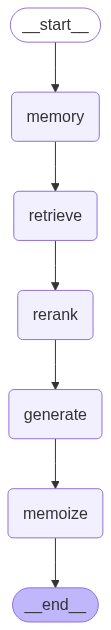

In [33]:
png = compiled_graph.get_graph().draw_mermaid_png()
display_image(png)

# Run Agentic Workflow

In [34]:
%%time

final_state = compiled_graph.invoke(
        input={
            # "docs": DOCS,
            # "file_id": FILE_ID,
            "question": QUESTION,
            "input_path": INPUT_PATH, 
            "memory": MEMORY, 
            "llm": qwen_agent,
            "messages": [],
        },
    )

CPU times: user 4.93 s, sys: 3.52 s, total: 8.46 s
Wall time: 4.71 s


# Generate Answer

In [36]:
answer = final_state.get('answer')
display(Markdown(answer))

The main idea of the content is to introduce an audio demo from the AGENTIC platform, which will be analyzed by the workflow, and invite questions about its content.

# Audio Timestamps and History

In [37]:
# Show supporting audio evidence with timestamps
# start_s/end_s are the exact spans the agent used.
# score is the similarity score from retrieval (CLAP cosine or your MMR score if you added it).

evidence = final_state.get("evidence", [])
if evidence:
    from tabulate import tabulate
    rows = [
        [e["file_name"], f'{e["start_s"]:.1f}', f'{e["end_s"]:.1f}', f'{e.get("score", 0):.3f}']
        for e in evidence
    ]
    print(tabulate(rows, headers=["file", "start_s", "end_s", "score"]))
else:
    print("(no evidence returned)")

# If you keep a 'messages' log in state, show it; otherwise skip
msgs = final_state.get("messages")
if msgs is not None:
    import json
    print(json.dumps(msgs, indent=2))

# pretty_json = json.dumps(final_state.get('messages'), indent=4)
# print(pretty_json)

file              start_s    end_s    score
--------------  ---------  -------  -------
sample_tts.mp3          0     13.4    0.252
[]


In [38]:
# Play back the top-N evidence windows (no transcription)
from IPython.display import Audio, display

def play_evidence(evidence, max_items=3):
    shown = 0
    for e in evidence:
        if shown >= max_items:
            break
        wav_path = ensure_wav(e["file_path"])
        audio, sr = sf.read(wav_path)
        if audio.ndim == 2:
            audio = audio.mean(axis=1)
        i0 = int(max(0, e["start_s"] * sr))
        i1 = int(min(len(audio), e["end_s"] * sr))
        if i1 <= i0:
            continue
        print(f"{e['file_name']} [{e['start_s']:.1f}s–{e['end_s']:.1f}s] score={e.get('score',0):.3f}")
        display(Audio(audio[i0:i1], rate=sr))
        shown += 1

# Usage
play_evidence(evidence, max_items=3)


sample_tts.mp3 [0.0s–13.4s] score=0.252


In [39]:
end_time: float = time.time()
elapsed_time: float = end_time - start_time
elapsed_minutes: int = int(elapsed_time // 60)
elapsed_seconds: float = elapsed_time % 60

logger.info(f"⏱️ Total execution time: {elapsed_minutes}m {elapsed_seconds:.2f}s")
logger.info("✅ Notebook execution completed successfully.")

INFO:AIS_logger:⏱️ Total execution time: 9m 33.27s


INFO:AIS_logger:✅ Notebook execution completed successfully.


Built with ❤️ using [**HP AI Studio**](https://hp.com/ai-studio).